# Task 2: Data Cleaning and Exploratory Data Analysis (EDA)

## Objective

#The objective of this task is to clean the Titanic dataset, handle missing values, identify duplicate records, 
#analyze relationships between variables, and extract meaningful insights using Exploratory Data Analysis (EDA).


Shape of Dataset: (891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


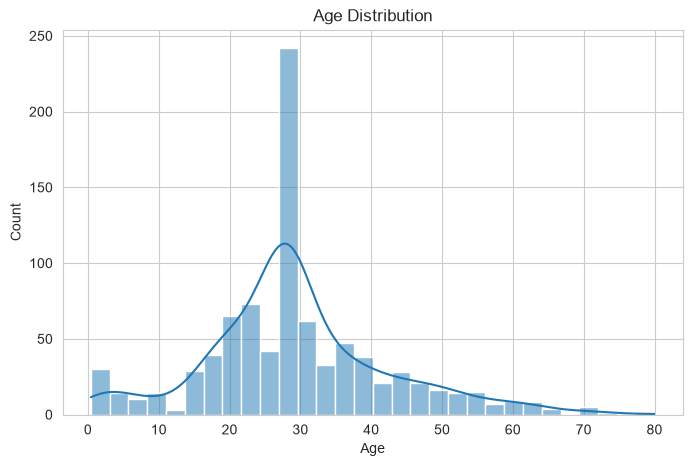

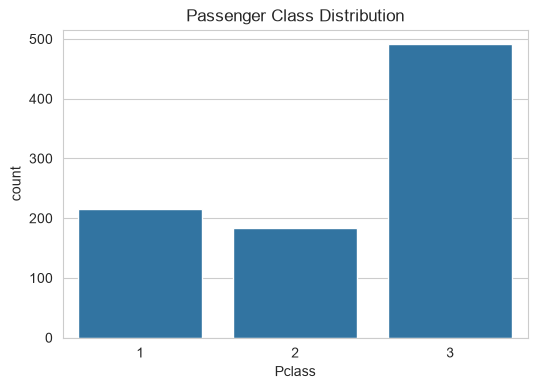

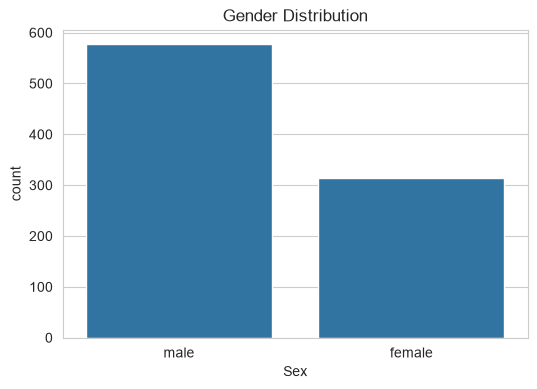

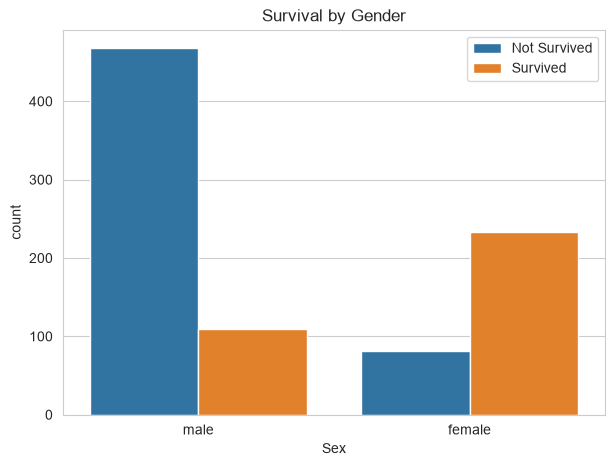

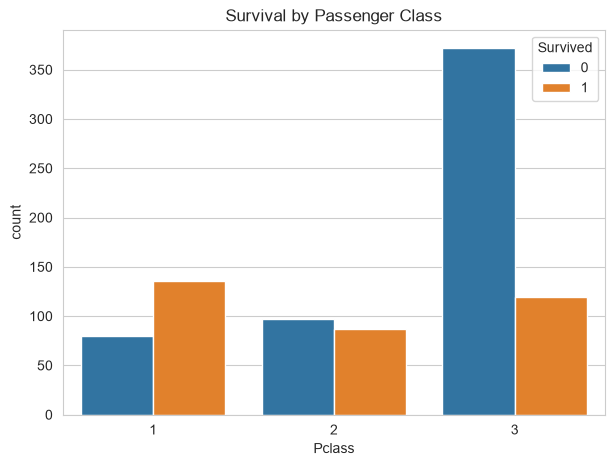

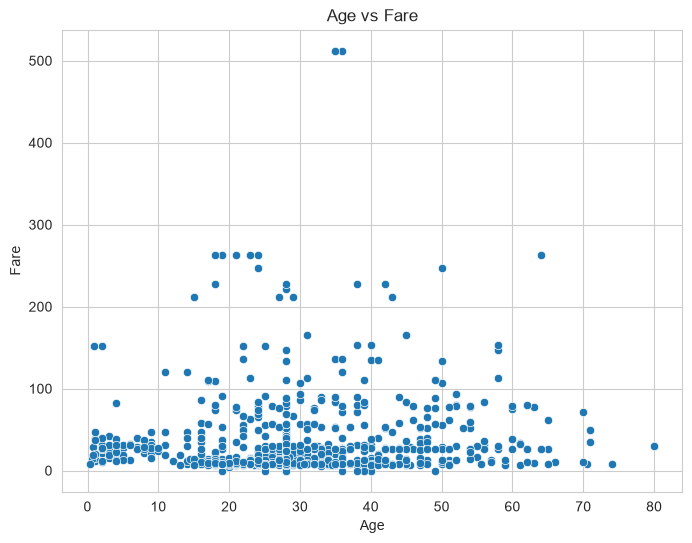

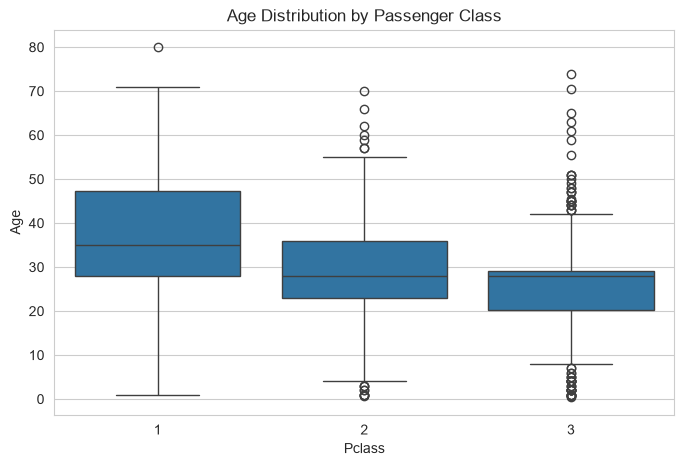

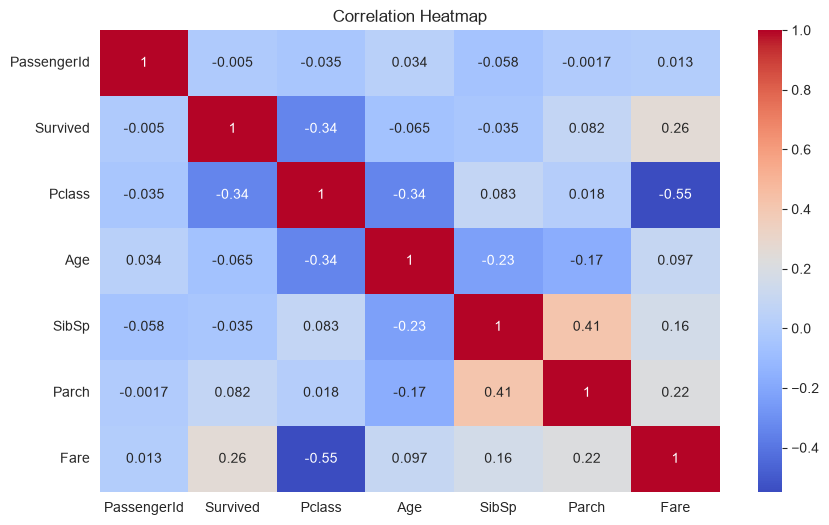

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
df = pd.read_csv("../datasets/titanic.csv")
df.head()
print("Shape of Dataset:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nInformation:")
df.info()
print("\nStatistical Summary:")
display(df.describe())
df.isnull().sum()

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop("Cabin", axis=1, inplace=True)
df.isnull().sum()

df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(7,5))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.legend(["Not Survived","Survived"])
plt.show()

plt.figure(figsize=(7,5))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x="Age", y="Fare", data=df)
plt.title("Age vs Fare")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="Pclass", y="Age", data=df)
plt.title("Age Distribution by Passenger Class")
plt.show()

plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include="number")
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Key Insights

#1. Missing values in Age and Embarked were successfully handled.
#2. Cabin column was removed due to a high percentage of missing values.
#3. Most passengers were between 20 and 40 years old.
#4. Third-class passengers formed the largest group.
#5. Female passengers had a higher survival rate than male passengers.
#6. First-class passengers had a better chance of survival.
#7. Fare showed a slight positive relationship with survival.
#8. The cleaned dataset is now suitable for machine learning.

# Conclusion

#The Titanic dataset was successfully cleaned and analyzed. 
#Missing values were handled appropriately, duplicate records were checked,
#and several visualizations revealed meaningful patterns.
#The cleaned dataset is now ready for predictive modeling and further machine learning tasks.